In [1]:
%matplotlib inline
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse
from scipy.signal import butter, filtfilt
from scipy import stats
from scipy.optimize import least_squares
import json

# calibrate gyroscope termometer

       now[ms]  AHT_tmp[C]  AHT_hum  BMP_temp[C]  BMP_pres     gx     gy  \
1000     79369       15.68    25.38        16.68    102642  1.389  1.573   
1001     79443       15.67    25.35        16.66    102641  1.748  1.641   
1002     79524       15.64    25.35        16.62    102641  1.748  1.473   
1003     79598       15.63    25.30        16.62    102641  1.885  1.802   
1004     79672       15.60    25.29        16.58    102640  1.763  1.634   
...        ...         ...      ...          ...       ...    ...    ...   
22995  1847392      -17.69    63.85       -16.96    102718  2.298  2.656   
22996  1847474      -17.69    63.84       -16.97    102718  2.588  2.450   
22997  1847556      -17.69    63.83       -16.97    102718  2.313  2.420   
22998  1847638      -17.68    63.85       -16.96    102720  2.557  2.427   
22999  1847725      -17.69    63.81       -16.96    102721  2.588  2.519   

          gz     ax     ay     az  gtemp    magx    magy   magz    volt  
1000  -0.344 

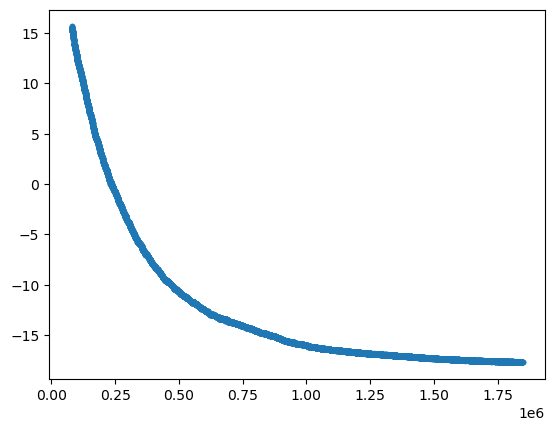

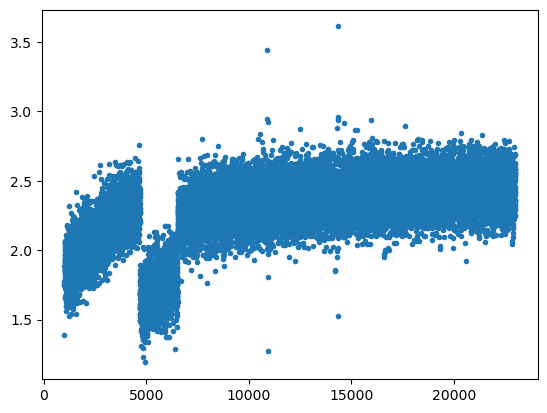

In [2]:
temp_calibration_data=pd.read_csv('temp-calibration.csv')[1000:23000]
print(temp_calibration_data)

plt.plot(temp_calibration_data['now[ms]'],temp_calibration_data['AHT_tmp[C]'],'.')
plt.show()
plt.plot(temp_calibration_data['gx'],'.')
plt.show()

In [3]:
sensors={"gyro":['gx','gy','gz'],"accel":['ax','ay','az'],"mag":['magx','magy','magz']}
offsets={}

## calibrate termometer of gyroscope with calibrated termometer

{'gtemp': {'offset': np.float64(21.892719725589476), 'scale': np.float64(0.8899545931264473)}}


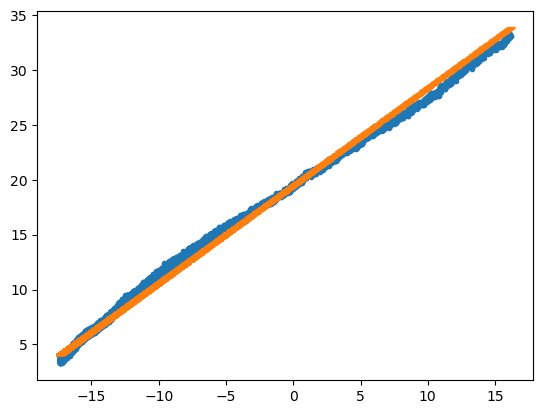

In [4]:
temp_calibration_data['tempOffset']=(temp_calibration_data['AHT_tmp[C]']+temp_calibration_data['BMP_temp[C]'])/2
linear=stats.linregress(temp_calibration_data['tempOffset'],temp_calibration_data['gtemp'])

offsets['gtemp']={'offset':linear.intercept/linear.slope,'scale':linear.slope}
print(offsets)
temp_calibration_data['gtemp_calibrated']=(temp_calibration_data['gtemp']-offsets['gtemp']['offset'])*offsets['gtemp']['scale']
plt.plot(temp_calibration_data['tempOffset'],temp_calibration_data['gtemp'],'.')
plt.plot(temp_calibration_data['tempOffset'],(temp_calibration_data['tempOffset']+offsets['gtemp']['offset'])*offsets['gtemp']['scale'],'_')
plt.show()

# find the absolute offsets at 0C


collect and plot data in real time

In [5]:
offsets={}
sensors={"gyro":['gx','gy','gz'],"accel":['ax','ay','az'],"mag":['magx','magy','magz']}
with open('calibration_offsets.json') as f:
    offsets=json.load(f)
print(offsets)
final_calibration_data=pd.read_csv('final-calibration.csv')

plt.plot(final_calibration_data['now[ms]'],final_calibration_data['ax'],'.')
plt.show()
plt.plot(final_calibration_data['now[ms]'],final_calibration_data['magx'],'.')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'calibration_offsets.json'

In [ ]:
print(offsets)
final_calibration_data['gtemp_calibrated']=(final_calibration_data['gtemp']-offsets['gtemp']['offset'])*offsets['gtemp']['scale']
for sensor in sensors:
    sns=sensors[sensor]
    for i in range(len(sns)):
        final_calibration_data[sns[i]+'_calibrated']=final_calibration_data[sns[i]]
        final_calibration_data[sns[i]+'_smoothed']=final_calibration_data[sns[i]+'_calibrated'].rolling(window=30).mean()

{'gtemp': {'offset': 21.892719725589476, 'scale': 0.8899545931264473}, 'gx': {'tempOffset': -0.021586792358359117, 'offset': 2.0293925221537843}, 'gy': {'tempOffset': -0.0203030523388205, 'offset': 2.0367279043462965}, 'gz': {'tempOffset': -0.005832454539831707, 'offset': -0.2910172807975372}, 'ax': {'offset': 0.03764483705436618, 'scale': 9.89667167880515}, 'ay': {'offset': 0.0039877343303261386, 'scale': 9.91839443251234}, 'az': {'offset': -0.0007502589765589077, 'scale': 9.620605996593481}, 'magx': {'offset': 499.22560443025856, 'scale': 0.00033468981790177587}, 'magy': {'offset': 406.10800404767446, 'scale': 0.00032792114858669303}, 'magz': {'offset': 254.62126909439348, 'scale': 0.0003375361890145562}}


In [ ]:
def fit_ellipsoid(points):
    # 1. Начальное приближение (берем среднее и размах данных)
    center_guess = np.mean(points, axis=0)
    # Радиусы примерно равны стандартному отклонению * 2 (или просто 1.0 для акселерометра)
    radii_guess = np.std(points, axis=0) * 2
    initial_params = np.concatenate([center_guess, radii_guess])

    # 2. Функция ошибки (расстояние от точки до поверхности эллипсоида)
    def residuals(p, pts):
        cx, cy, cz, rx, ry, rz = p
        # Уравнение эллипсоида: (x-cx)^2/rx^2 + (y-cy)^2/ry^2 + (z-cz)^2/rz^2 - 1 = 0
        # Мы возвращаем вектор ошибок для каждой точки
        val = ((pts[:, 0] - cx)**2 / rx**2 + 
               (pts[:, 1] - cy)**2 / ry**2 + 
               (pts[:, 2] - cz)**2 / rz**2) - 1
        return val

    # 3. Запуск оптимизации
    # Используем метод 'soft_l1' для устойчивости к выбросам (outliers)
    res = least_squares(residuals, initial_params, args=(points,), loss='soft_l1')
    
    center = res.x[:3]
    radii = np.abs(res.x[3:]) # Радиусы всегда берем по модулю
    
    return center, radii

gyro
[ 2.04625468e+02 -1.02726551e+06  3.46025147e+02] [  44755.68189345 1027298.68979193   55299.14672963]


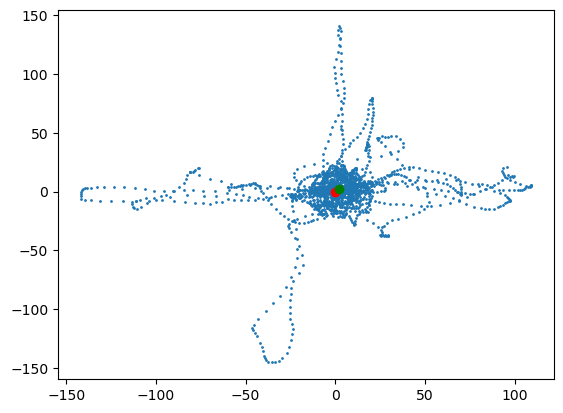

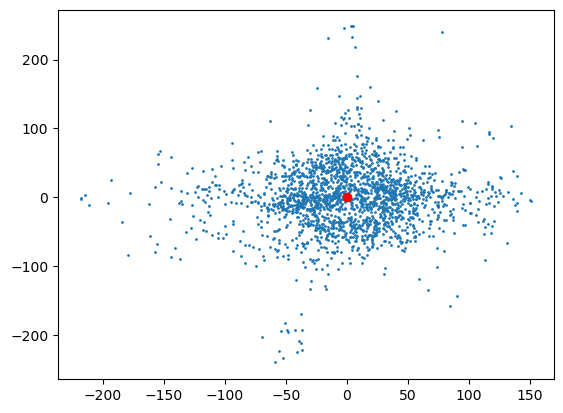

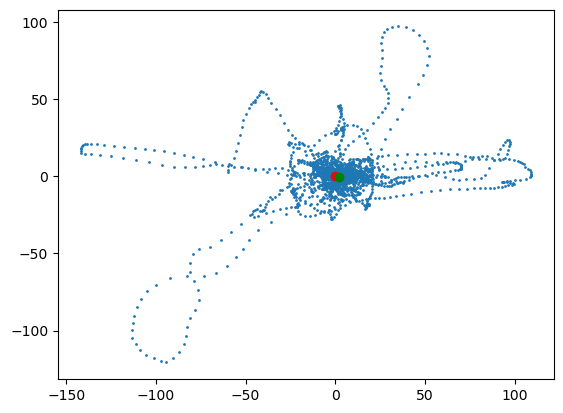

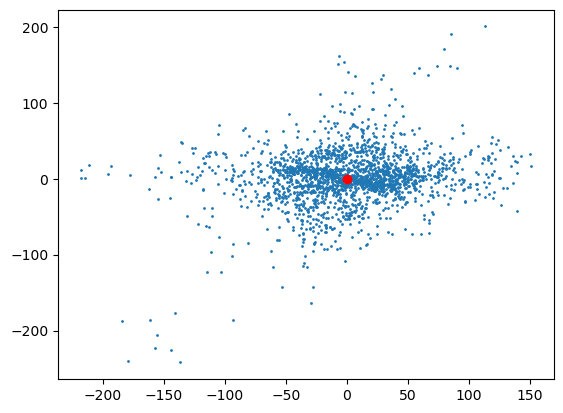

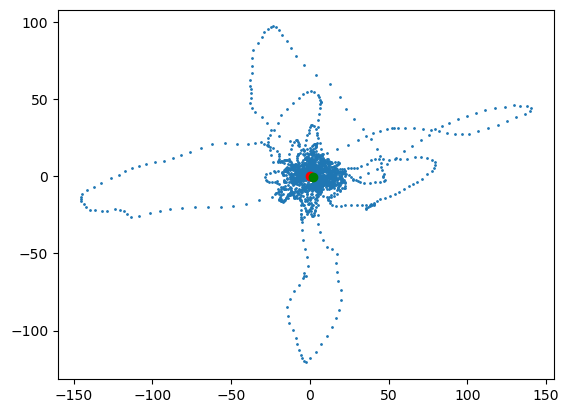

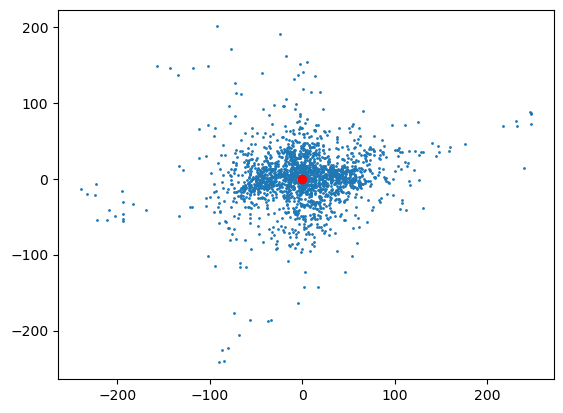

accel
[ 0.03537847 -0.01091907 -0.00601157] [0.95580192 0.97160526 1.00053649]


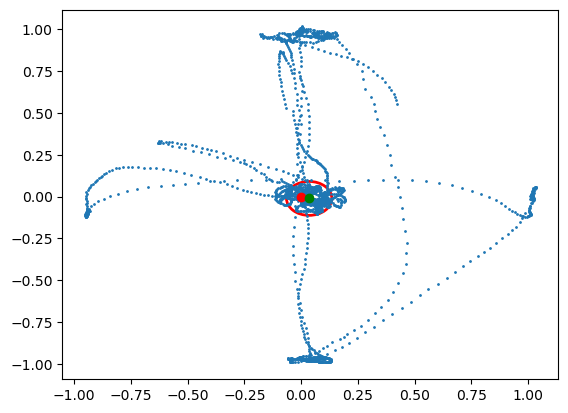

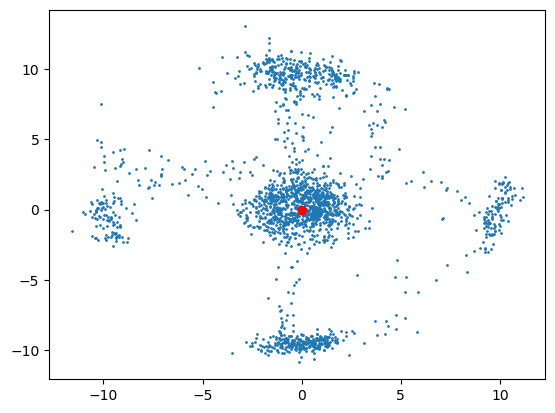

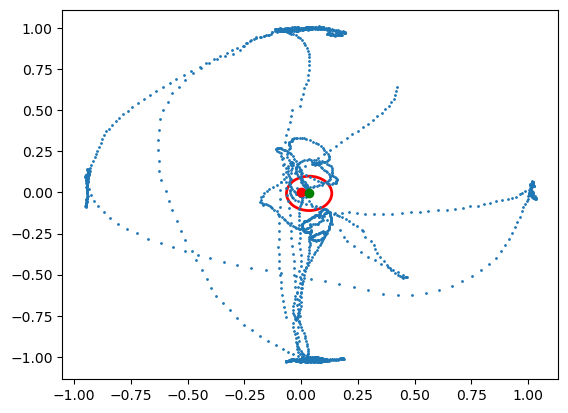

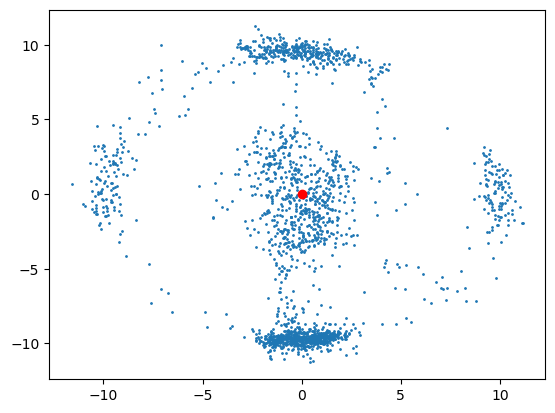

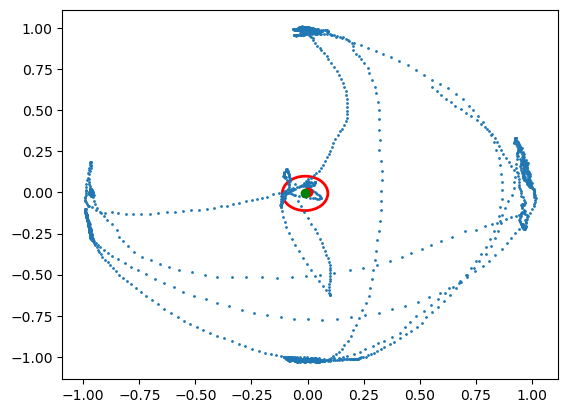

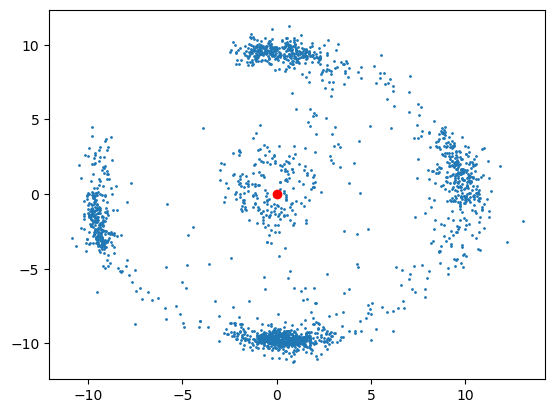

mag
[5.36687029 0.00672197 1.99594268] [60.30583857 57.76607975 63.13086929]


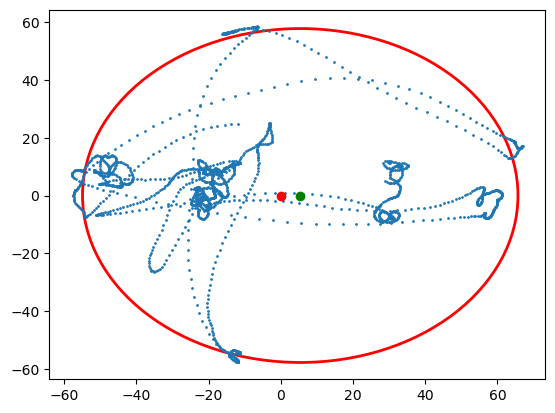

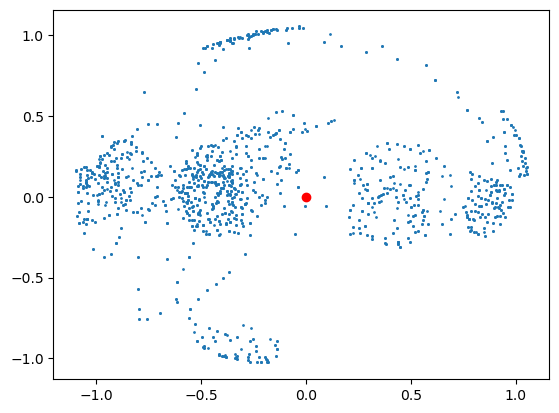

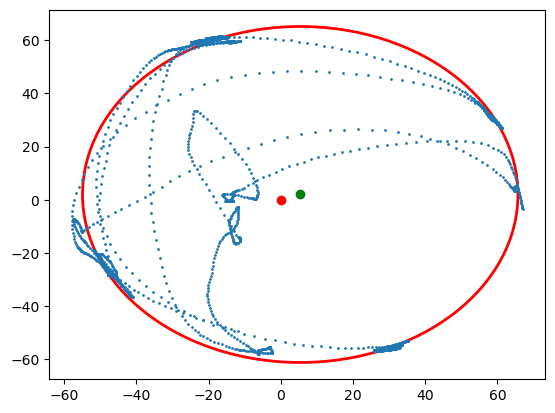

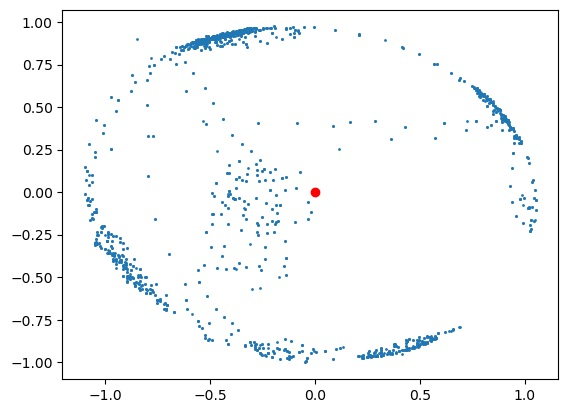

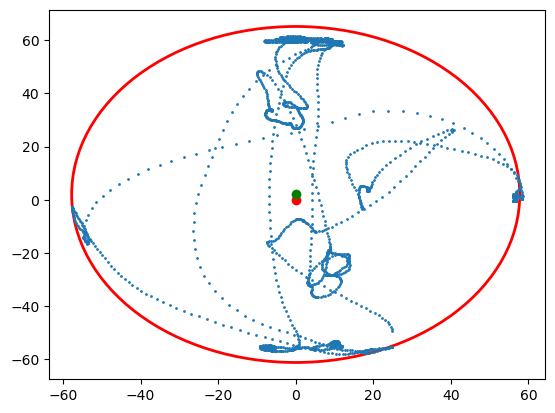

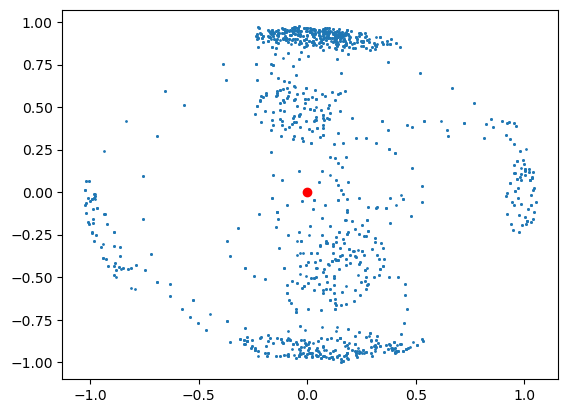

In [ ]:
defaults={'accel':9.81}
for sensor in sensors:
    print(sensor)
    sns=sensors[sensor]
    
    C, r2=fit_ellipsoid(final_calibration_data[[sns[0]+'_smoothed',sns[1]+'_smoothed',sns[2]+'_smoothed']].dropna().values)
    print(C,r2)
    if(sensor=='accel'):
        r2=r2/np.mean(r2)/defaults[sensor]

    for i in range(len(sns)):
        if sensor!='gyro':
            offsets[sns[i]]={'offset':C[i],'scale':(1/r2[i])}
            final_calibration_data[sns[i]+'_final_calibrated']=(final_calibration_data[sns[i]+'_calibrated']-offsets[sns[i]]['offset'])*offsets[sns[i]]['scale']
        else:
            final_calibration_data[sns[i]+'_final_calibrated']=(final_calibration_data[sns[i]+'_calibrated']-offsets[sns[i]]['offset'])
    for i in range(len(sns)):

        for j in range(i+1,len(sns)):
            ax = plt.gca()

            if(sensor!='gyro'):
                ellipse = Ellipse(xy=(offsets[sns[i]]['offset'],offsets[sns[j]]['offset']), width=1/offsets[sns[i]]['scale']*2, height=1/offsets[sns[j]]['scale']*2, edgecolor='r', fc='None', lw=2)
                ax.add_patch(ellipse)

            ax=plt.scatter(final_calibration_data[sns[i]+'_smoothed'],final_calibration_data[sns[j]+'_smoothed'],s=1)
            
            plt.plot(0,0,'o',color='red')
            plt.plot(offsets[sns[i]]['offset'],offsets[sns[j]]['offset'],'o',color='green')
            plt.show()

            ax=plt.scatter(final_calibration_data[sns[i]+'_final_calibrated'],final_calibration_data[sns[j]+'_final_calibrated'],s=1)
            
            plt.plot(0,0,'o',color='red')
            plt.show()

        



In [ ]:
print(offsets)
with open('calibration_offsets.json', 'w') as f:
    f.write(json.dumps(offsets))

{'gtemp': {'offset': 21.892719725589476, 'scale': 0.8899545931264473}, 'gx': {'tempOffset': -0.021586792358359117, 'offset': 2.0293925221537843}, 'gy': {'tempOffset': -0.0203030523388205, 'offset': 2.0367279043462965}, 'gz': {'tempOffset': -0.005832454539831707, 'offset': -0.2910172807975372}, 'ax': {'offset': np.float64(0.035378469830884045), 'scale': np.float64(10.01711296392382)}, 'ay': {'offset': np.float64(-0.010919070720751357), 'scale': np.float64(9.854182783125843)}, 'az': {'offset': np.float64(-0.0060115734257293755), 'scale': np.float64(9.569241972040562)}, 'magx': {'offset': np.float64(5.366870287924152), 'scale': np.float64(0.016582142355231737)}, 'magy': {'offset': np.float64(0.006721965124168969), 'scale': np.float64(0.017311197233859283)}, 'magz': {'offset': np.float64(1.995942680175688), 'scale': np.float64(0.015840111362090927)}}


## generate code for stratospheric probe calibration

In [ ]:
offsets={}
output=''
sensors={"gyro":['gx','gy','gz'],"accel":['ax','ay','az'],"mag":['magx','magy','magz'],'gtemp':['gtemp']}
with open('calibration_offsets.json') as f:
    offsets=json.load(f)
axnames=['x','y','z']
for sensor in sensors:
    sns=sensors[sensor]
    for i in range(len(sns)):
        for key in offsets[sns[i]]:
            if(len(sns)==3):
                output=output+'calibrator.'+sensor+'.'+key+'.'+axnames[i]+'='+str(offsets[sns[i]][key])+';\n'
            else:
                output=output+'calibrator.'+sensor+'.'+key+'='+str(offsets[sns[i]][key])+';\n'
print(output)

calibrator.gyro.tempOffset.x=-0.021586792358359117;
calibrator.gyro.offset.x=2.0293925221537843;
calibrator.gyro.tempOffset.y=-0.0203030523388205;
calibrator.gyro.offset.y=2.0367279043462965;
calibrator.gyro.tempOffset.z=-0.005832454539831707;
calibrator.gyro.offset.z=-0.2910172807975372;
calibrator.accel.offset.x=0.035378469830884045;
calibrator.accel.scale.x=10.01711296392382;
calibrator.accel.offset.y=-0.010919070720751357;
calibrator.accel.scale.y=9.854182783125843;
calibrator.accel.offset.z=-0.0060115734257293755;
calibrator.accel.scale.z=9.569241972040562;
calibrator.mag.offset.x=5.366870287924152;
calibrator.mag.scale.x=0.016582142355231737;
calibrator.mag.offset.y=0.006721965124168969;
calibrator.mag.scale.y=0.017311197233859283;
calibrator.mag.offset.z=1.995942680175688;
calibrator.mag.scale.z=0.015840111362090927;
calibrator.gtemp.offset=21.892719725589476;
calibrator.gtemp.scale=0.8899545931264473;

